# ImageNet-100 — Transfer Learning with ResNet-34

Fine-tuning a pre-trained ResNet-34 (ImageNet weights) on ImageNet-100.

**Strategy:**
- Resize ImageNet-100 images from 224×224 (ImageNet standard)
- Load `resnet34(weights='DEFAULT')` with pre-trained weights
- Replace the final FC layer for 10 classes
- Fine-tune with SGD + OneCycleLR (lower max_lr since weights are already good)
- Use `ModelCheckpoint` for crash protection & best model saving

## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim

from utils.dataset import get_imagenet100_dataloaders
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch


## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')


Using device: cuda


## Data Pipeline

Since the pre-trained ResNet-34 was trained on 224×224 ImageNet images,
we resize ImageNet-100 images to 224×224 to match the expected input resolution.
We use ImageNet normalization stats since the backbone was pre-trained with them.

In [3]:
batch_size = 128  # Smaller batch for 224×224 images

trainloader, valloader, testloader = get_imagenet100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')


C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Dataset] Loading 'ilee0022/ImageNet100' (local cache: C:\Users\asmit\PycharmProjects\CIFAR_10\data\huggingface)...
Train batches: 915 | Val batches: 40 | Test batches: 102


## Visualize Sample Batch

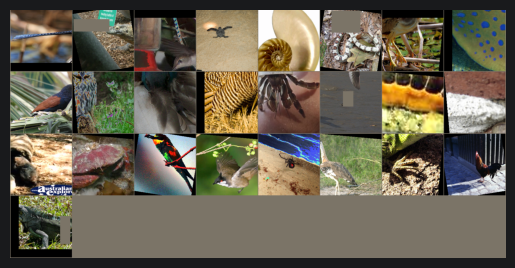

37    20    30    65    80    13    0     54    90    55    21    82    53    66    68    62    28    33    4     41    83    27    26    94    36   


In [4]:
show_sample_batch(trainloader, [str(i) for i in range(100)], n=25)


## Model: Pre-trained ResNet-34

We load the ResNet-34 backbone with ImageNet weights,
then replace the final fully connected layer to output 10 classes.

The `BasicBlock` structure is identical to our custom ResNet-18,
but ResNet-34 is deeper (34 layers vs 18), giving it more capacity
to learn complex features — all while keeping the same lightweight block design.

In [5]:
model = models.resnet34(weights='DEFAULT')

# Replace the final FC layer (1000 classes → 100 for CIFAR-100)
num_features = model.fc.in_features  # 512
model.fc = nn.Linear(num_features, 100)

model.to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


Model parameters: 21,335,972


## Training Configuration

Since the backbone is already pre-trained, we use a **lower max learning rate** (`0.01`)
compared to training from scratch (`0.1`). This prevents the fine-tuning from
destroying the pre-trained features.

In [6]:
criterion = nn.CrossEntropyLoss()
epochs = 30
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e3,
)

scaler = torch.amp.GradScaler('cuda')
NAME = 'resnet34_transfer_imagenet100'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=False,
)


## Training Loop

In [7]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint, log=True
)


[RunLogger] Logging to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\ipykernel_launcher/'  —  run: 'resnet_20260607_121115'
Epoch [ 1/30]  Train Loss: 1.4935  Val Loss: 0.6188  Val Acc: 81.34%  LR: 0.001271  Time: 151.06s
Epoch [ 2/30]  Train Loss: 0.8750  Val Loss: 0.6049  Val Acc: 81.82%  LR: 0.002053  Time: 144.97s
Epoch [ 3/30]  Train Loss: 0.8430  Val Loss: 0.6133  Val Acc: 81.34%  LR: 0.003250  Time: 146.57s
Epoch [ 4/30]  Train Loss: 0.8507  Val Loss: 0.6661  Val Acc: 80.68%  LR: 0.004719  Time: 133.09s
Epoch [ 5/30]  Train Loss: 0.8581  Val Loss: 0.6483  Val Acc: 80.98%  LR: 0.006282  Time: 143.29s
Epoch [ 6/30]  Train Loss: 0.8572  Val Loss: 0.6966  Val Acc: 79.06%  LR: 0.007751  Time: 138.70s
Epoch [ 7/30]  Train Loss: 0.8543  Val Loss: 0.6938  Val Acc: 79.66%  LR: 0.008948  Time: 137.00s
Epoch [ 8/30]  Train Loss: 0.8474  Val Loss: 0.6732  Val Acc: 80.30%  LR: 0.009729  Time: 136.06s
Epoch [ 9/30]  Train Loss: 0.8475  Val Loss: 0.6958  Val Acc: 79.22%  LR: 0.010000  Time: 13

## Restore Best Weights & Test Evaluation

In [8]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, [str(i) for i in range(100)], device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')



Overall Test Accuracy: 89.37%

  0    : 97.6%
  1    : 90.8%
  2    : 98.4%
  3    : 96.7%
  4    : 98.3%
  5    : 94.6%
  6    : 85.1%
  7    : 91.2%
  8    : 88.2%
  9    : 86.6%
  10   : 95.7%
  11   : 91.5%
  12   : 70.0%
  13   : 90.1%
  14   : 60.6%
  15   : 56.6%
  16   : 93.0%
  17   : 92.2%
  18   : 81.9%
  19   : 86.2%
  20   : 96.7%
  21   : 92.8%
  22   : 96.2%
  23   : 81.1%
  24   : 85.1%
  25   : 99.4%
  26   : 91.2%
  27   : 94.1%
  28   : 94.9%
  29   : 96.6%
  30   : 95.2%
  31   : 100.0%
  32   : 93.5%
  33   : 84.3%
  34   : 93.4%
  35   : 85.5%
  36   : 91.7%
  37   : 97.2%
  38   : 80.1%
  39   : 96.4%
  40   : 92.7%
  41   : 95.6%
  42   : 94.7%
  43   : 89.1%
  44   : 89.5%
  45   : 95.7%
  46   : 88.2%
  47   : 92.1%
  48   : 70.3%
  49   : 78.7%
  50   : 51.2%
  51   : 96.5%
  52   : 88.2%
  53   : 90.9%
  54   : 73.2%
  55   : 100.0%
  56   : 83.1%
  57   : 96.5%
  58   : 97.4%
  59   : 90.0%
  60   : 82.6%
  61   : 98.4%
  62   : 87.1%
  63   : 97.7%
  64  

## Training Curves

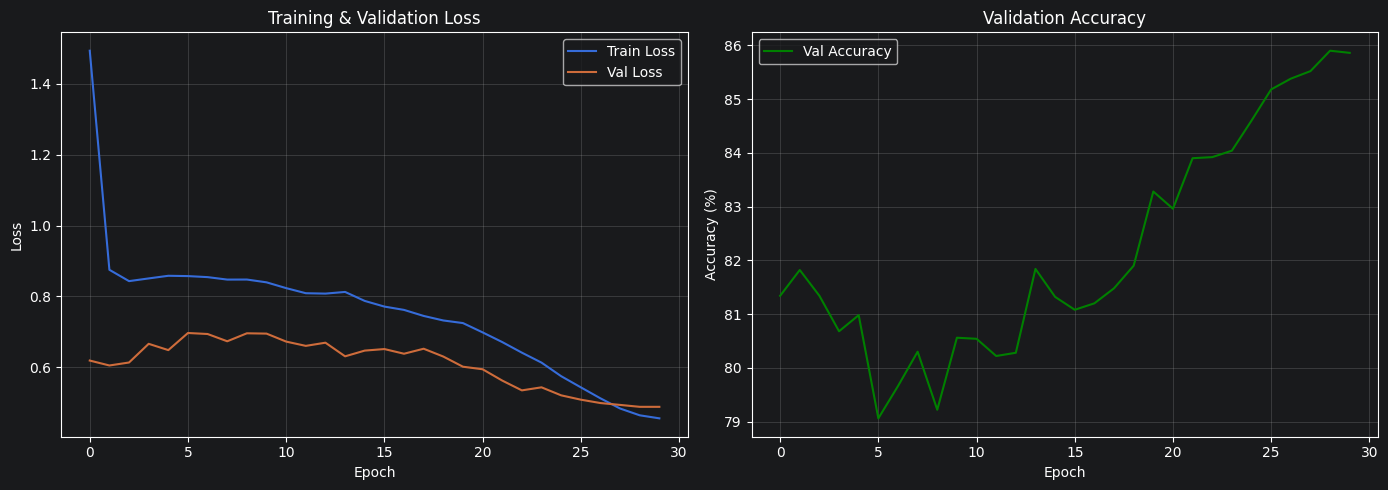

In [9]:
plot_training_curves(train_losses, val_losses, val_accuracies)
